# Context dependency: RNA-FM vs ERNIE-RNA vs RiNALMo

**The core question**: if you embed a long genomic region containing a known ncRNA,
can you still *find* that ncRNA by sliding through the embedding and matching
against the standalone reference?

RNA-FM is known to be highly context-dependent: adding/removing a few flanking
nucleotides changes per-nucleotide embeddings drastically. This forced the
current pipeline into expensive per-window re-embedding.

**Tests:**
1. **Stability**: embed tRNA standalone vs. with +10/20/50/100 nt flanks.
   Compare embeddings at core positions.
2. **Findability**: embed tRNA inside a ~300 nt genomic region. Slide a
   tRNA-length window through the long embedding (just numpy slicing, no
   re-embedding). Does the MMD minimum land at the correct position?

In [1]:
import sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "modules" / "RNA-FM"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "RiNALMo"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "pipeline"))

import short_ncrna as sn
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

SEED = 42
random.seed(SEED); np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

Device: mps


In [2]:
# --- Load all 3 models ---
import fm
fm_model, fm_alpha = fm.pretrained.rna_fm_t12()
fm_model.eval().to(device)
fm_bc = fm_alpha.get_batch_converter()

def emb_rnafm(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    _, _, tk = fm_bc([("x", rna)])
    tk = tk.to(device)
    with torch.no_grad():
        out = fm_model(tk, repr_layers=[12])["representations"][12]
    return out[0, 1:1 + len(rna), :].cpu().float().numpy()

import multimolecule
from transformers import AutoTokenizer, AutoModel
ern_tokenizer = AutoTokenizer.from_pretrained("multimolecule/ernierna", trust_remote_code=True)
ern_model = AutoModel.from_pretrained("multimolecule/ernierna", trust_remote_code=True)
ern_model = ern_model.to(device).eval()

def emb_ernierna(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    inputs = ern_tokenizer(rna, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = ern_model(**inputs, output_hidden_states=True)
    return out.last_hidden_state[0, 1:1 + len(rna), :].cpu().float().numpy()

from rinalmo.pretrained import get_pretrained_model
rin_model, rin_alpha = get_pretrained_model(model_name="giga-v1")
rin_model = rin_model.to(device).eval()

def emb_rinalmo(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    tokens = torch.tensor(
        rin_alpha.batch_tokenize([rna]), dtype=torch.int64, device=device
    )
    with torch.no_grad():
        out = rin_model(tokens)
    return out["representation"][0, 1:1 + len(rna), :].cpu().float().numpy()

MODELS = {
    "RNA-FM":     {"emb_fn": emb_rnafm,   "dim": 640},
    "ERNIE-RNA":  {"emb_fn": emb_ernierna, "dim": 768},
    "RiNALMo":    {"emb_fn": emb_rinalmo,  "dim": 1280},
}
print(f"All {len(MODELS)} models loaded")

/Users/Bogdan.Kirilenko/Developer/CURIA_pipeline/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0615 12:00:31.661000 11275 .venv/lib/python3.14/site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5267.26it/s]
[transformers] ErnieRnaModel LOAD REPORT from: multimolecule/ernierna
Key                                 | Status     |  | 
------------------------------------+------------+--+-
lm_head.transform.dense.bias        | UNEXPECTED |  | 
lm_head.bias                        | UNEXPECTED |  | 
lm_head.transform.dense.weight      | UNEXPECTED |  | 
lm_head.transform.layer_norm.bias   | UNEXPECTED |  | 
lm_head.transform.layer_norm.weight | UNEXPECTED |  | 


All 3 models loaded


## Extract tRNA with genomic flanking context

Use the tRNA-Asn (copy 1) from previous notebooks. Extract the real genomic
flanking sequence so the context is biologically realistic (not random).

In [3]:
BED_PATH    = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.input.w.tRNA.bed"
TWOBIT_PATH = REPO_ROOT / "input_data" / "2bit" / "hg38.2bit"

accessor = TwoBitAccessor(str(TWOBIT_PATH))
bed_data = read_bed12_file(str(BED_PATH))

# Find our tRNA
TARGET_ID = "tRNA-Asn-GTT-chr1-140"
target = None
for t in bed_data:
    if t.id == TARGET_ID:
        target = t
        break
assert target is not None

# Get the core tRNA sequence (spliced)
core_seq = sn._get_spliced_sequence(target, accessor).upper().replace("T", "U")
core_len = len(core_seq)
print(f"Core: {TARGET_ID}, {core_len} nt")
print(f"Genomic: {target.chrom}:{target.start}-{target.end} ({'+' if target.strand >= 0 else '-'})")

# Get flanking genomic sequence
# For a minus-strand gene, "upstream" flank is to the right in genome coords
MAX_FLANK = 150  # max flank on each side
if target.strand >= 0:
    left_start = max(0, target.start - MAX_FLANK)
    right_end = target.end + MAX_FLANK
    left_flank = str(accessor.fetch(target.chrom, left_start, target.start)).upper().replace("T", "U")
    right_flank = str(accessor.fetch(target.chrom, target.end, right_end)).upper().replace("T", "U")
else:
    # Minus strand: need to reverse complement
    comp = {"A": "U", "T": "A", "G": "C", "C": "G", "N": "N"}
    right_end = target.end + MAX_FLANK
    left_start = max(0, target.start - MAX_FLANK)
    right_raw = str(accessor.fetch(target.chrom, target.end, right_end)).upper()
    left_raw = str(accessor.fetch(target.chrom, left_start, target.start)).upper()
    # For minus strand: upstream is right in genome, downstream is left
    left_flank = "".join(comp.get(b, "N") for b in reversed(right_raw))
    right_flank = "".join(comp.get(b, "N") for b in reversed(left_raw))

print(f"Left flank:  {len(left_flank)} nt")
print(f"Right flank: {len(right_flank)} nt")

# Verify: the core should be the same
full_seq = left_flank + core_seq + right_flank
core_start_in_full = len(left_flank)
core_end_in_full = core_start_in_full + core_len
assert full_seq[core_start_in_full:core_end_in_full] == core_seq
print(f"\nFull sequence: {len(full_seq)} nt (flank + core + flank)")
print(f"Core position in full: [{core_start_in_full}:{core_end_in_full}]")

Core: tRNA-Asn-GTT-chr1-140, 74 nt
Genomic: chr1:16520584-16520658 (-)
Left flank:  150 nt
Right flank: 150 nt

Full sequence: 374 nt (flank + core + flank)
Core position in full: [150:224]


## Test 1 — Embedding stability with increasing flanks

Embed the tRNA standalone, then with +10/20/50/100/150 nt flanks on each side.
Extract core positions from the flanked embedding. Measure:
- **Cosine similarity** between each core nucleotide's embedding (standalone vs in-context)
- **MMD** between the two sets of core embeddings

In [4]:
FLANKS = [0, 10, 20, 50, 100, 150]

# Build flanked sequences
flanked_seqs = {}
for f in FLANKS:
    if f == 0:
        flanked_seqs[f] = core_seq
    else:
        l = left_flank[-f:] if f <= len(left_flank) else left_flank
        r = right_flank[:f] if f <= len(right_flank) else right_flank
        flanked_seqs[f] = l + core_seq + r
    print(f"  flank={f:>3d}: {len(flanked_seqs[f])} nt")

  flank=  0: 74 nt
  flank= 10: 94 nt
  flank= 20: 114 nt
  flank= 50: 174 nt
  flank=100: 274 nt
  flank=150: 374 nt


In [5]:
# Embed all flanked versions, extract core positions, compare to standalone
from scipy.spatial.distance import cosine

stability_rows = []

for mname, minfo in MODELS.items():
    fn = minfo["emb_fn"]
    print(f"\n=== {mname} ===")

    # Standalone embedding = ground truth
    standalone = fn(core_seq)  # (core_len, D)

    for f in FLANKS:
        seq = flanked_seqs[f]
        full_emb = fn(seq)  # (len(seq), D)

        # Extract core positions
        if f == 0:
            core_emb = full_emb
        else:
            actual_left = min(f, len(left_flank))
            core_emb = full_emb[actual_left:actual_left + core_len]

        assert core_emb.shape[0] == core_len, f"Shape mismatch: {core_emb.shape[0]} vs {core_len}"

        # Per-nucleotide cosine similarity
        cos_sims = [1.0 - cosine(standalone[i], core_emb[i]) for i in range(core_len)]
        mean_cos = np.mean(cos_sims)
        min_cos = np.min(cos_sims)

        # MMD between the two sets
        mmd = sn._compute_mmd(standalone, core_emb)

        # Frobenius norm of difference (normalized)
        frob = np.linalg.norm(standalone - core_emb) / np.sqrt(core_len)

        stability_rows.append({
            "model": mname, "flank": f,
            "mean_cosine": mean_cos, "min_cosine": min_cos,
            "mmd": mmd, "frob_norm": frob,
        })
        print(f"  flank={f:>3d}: cos={mean_cos:.4f} (min={min_cos:.4f}), MMD={mmd:.4f}, frob={frob:.2f}")

stab_df = pd.DataFrame(stability_rows)


=== RNA-FM ===
  flank=  0: cos=1.0000 (min=1.0000), MMD=0.0000, frob=0.00
  flank= 10: cos=0.8498 (min=0.7995), MMD=0.1900, frob=7.40
  flank= 20: cos=0.8465 (min=0.7919), MMD=0.1933, frob=7.47
  flank= 50: cos=0.8492 (min=0.7924), MMD=0.1856, frob=7.40
  flank=100: cos=0.8414 (min=0.7905), MMD=0.1883, frob=7.59
  flank=150: cos=0.8338 (min=0.7798), MMD=0.1949, frob=7.77

=== ERNIE-RNA ===
  flank=  0: cos=1.0000 (min=1.0000), MMD=0.0000, frob=0.00
  flank= 10: cos=0.7970 (min=0.6809), MMD=0.0856, frob=7.25
  flank= 20: cos=0.7338 (min=0.5658), MMD=0.0994, frob=8.29
  flank= 50: cos=0.6006 (min=0.4568), MMD=0.1441, frob=10.15
  flank=100: cos=0.5920 (min=0.4437), MMD=0.1419, frob=10.29
  flank=150: cos=0.5856 (min=0.4464), MMD=0.1499, frob=10.36

=== RiNALMo ===
  flank=  0: cos=1.0000 (min=1.0000), MMD=0.0000, frob=0.00
  flank= 10: cos=0.9401 (min=0.7663), MMD=0.0000, frob=12.01
  flank= 20: cos=0.9338 (min=0.7746), MMD=0.0000, frob=12.63
  flank= 50: cos=0.9196 (min=0.8049), MMD=0

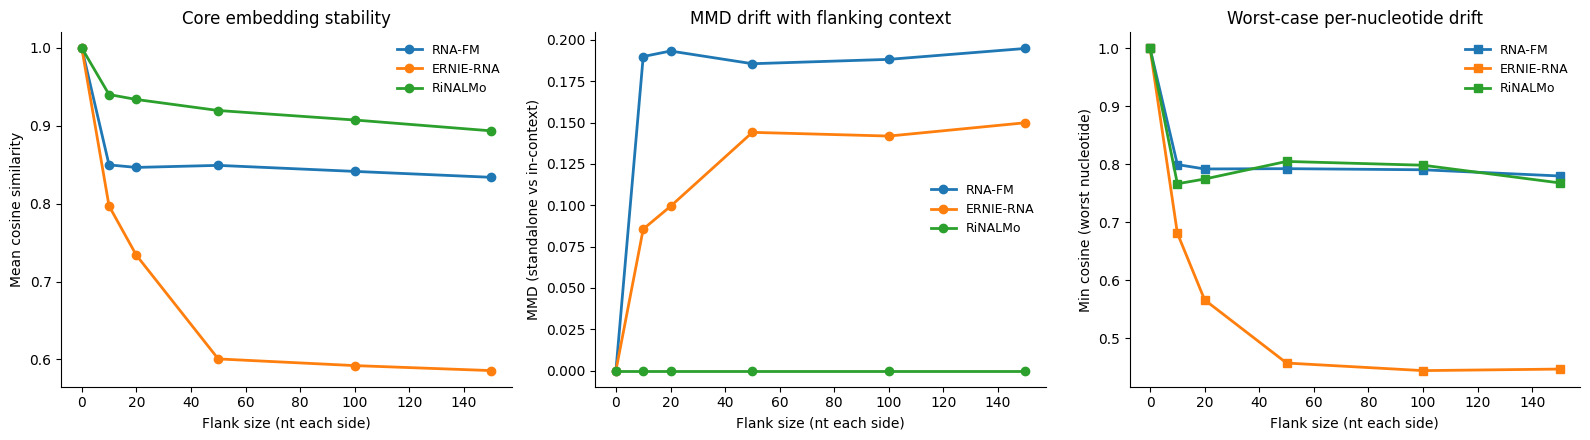

In [6]:
# Plot stability: cosine similarity and MMD vs flank size
model_colors = {"RNA-FM": "#1f77b4", "ERNIE-RNA": "#ff7f0e", "RiNALMo": "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: Mean cosine similarity
ax = axes[0]
for mname in MODELS:
    sub = stab_df[stab_df.model == mname]
    ax.plot(sub["flank"], sub["mean_cosine"], marker="o", ms=6,
            color=model_colors[mname], label=mname, lw=2)
ax.set_xlabel("Flank size (nt each side)")
ax.set_ylabel("Mean cosine similarity")
ax.set_title("Core embedding stability")
ax.set_ylim(None, 1.02)
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel 2: MMD
ax = axes[1]
for mname in MODELS:
    sub = stab_df[stab_df.model == mname]
    ax.plot(sub["flank"], sub["mmd"], marker="o", ms=6,
            color=model_colors[mname], label=mname, lw=2)
ax.set_xlabel("Flank size (nt each side)")
ax.set_ylabel("MMD (standalone vs in-context)")
ax.set_title("MMD drift with flanking context")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel 3: Min cosine (worst-case nucleotide)
ax = axes[2]
for mname in MODELS:
    sub = stab_df[stab_df.model == mname]
    ax.plot(sub["flank"], sub["min_cosine"], marker="s", ms=6,
            color=model_colors[mname], label=mname, lw=2)
ax.set_xlabel("Flank size (nt each side)")
ax.set_ylabel("Min cosine (worst nucleotide)")
ax.set_title("Worst-case per-nucleotide drift")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Test 2 — Findability: can you locate the ncRNA by sliding through a long embedding?

The practical test for a simpler pipeline:
1. Embed the full ~370 nt region (150 flank + 74 core + 150 flank) **once**
2. Embed the standalone tRNA **once** as reference
3. Slide a 74-nt window through the long embedding (numpy slicing only)
4. Compute MMD at each position
5. Check: does the minimum MMD land at the correct position?

If yes → you can replace the expensive per-window re-embedding with a single
forward pass + numpy sliding window.

In [7]:
# Use the full flanked sequence (max flank on each side)
full = flanked_seqs[max(FLANKS)]
actual_left_flank = min(max(FLANKS), len(left_flank))
true_start = actual_left_flank  # where the core tRNA starts in the full seq
true_end = true_start + core_len

print(f"Full sequence: {len(full)} nt")
print(f"Core tRNA at positions [{true_start}:{true_end}] (len={core_len})")
print(f"Sliding window size = {core_len} nt, stride = 1")
print(f"Total windows: {len(full) - core_len + 1}")

Full sequence: 374 nt
Core tRNA at positions [150:224] (len=74)
Sliding window size = 74 nt, stride = 1
Total windows: 301


In [8]:
# Findability: embed long once, slide through, compute MMD at each position
find_results = {}  # model -> {mmd_profile, best_pos, ...}

for mname, minfo in MODELS.items():
    fn = minfo["emb_fn"]
    print(f"\n=== {mname} ===")

    # Embed standalone reference
    ref_emb = fn(core_seq)  # (core_len, D)

    # Embed full region once
    full_emb = fn(full)  # (len(full), D)

    # Slide window through full_emb (numpy only, no re-embedding)
    n_windows = len(full) - core_len + 1
    mmd_profile = np.zeros(n_windows)
    for i in range(n_windows):
        window_emb = full_emb[i:i + core_len]  # (core_len, D) — just a slice
        mmd_profile[i] = sn._compute_mmd(ref_emb, window_emb)

    best_pos = int(np.argmin(mmd_profile))
    best_mmd = mmd_profile[best_pos]
    offset = best_pos - true_start

    find_results[mname] = {
        "mmd_profile": mmd_profile,
        "best_pos": best_pos,
        "best_mmd": best_mmd,
        "offset": offset,
    }

    print(f"  True position:  {true_start}")
    print(f"  Found position: {best_pos} (offset = {offset:+d})")
    print(f"  Best MMD:       {best_mmd:.4f}")
    print(f"  MMD at true:    {mmd_profile[true_start]:.4f}")

print("\nDone")


=== RNA-FM ===
  True position:  150
  Found position: 147 (offset = -3)
  Best MMD:       0.1913
  MMD at true:    0.1949

=== ERNIE-RNA ===
  True position:  150
  Found position: 91 (offset = -59)
  Best MMD:       0.1218
  MMD at true:    0.1499

=== RiNALMo ===
  True position:  150
  Found position: 141 (offset = -9)
  Best MMD:       0.0000
  MMD at true:    0.0000

Done


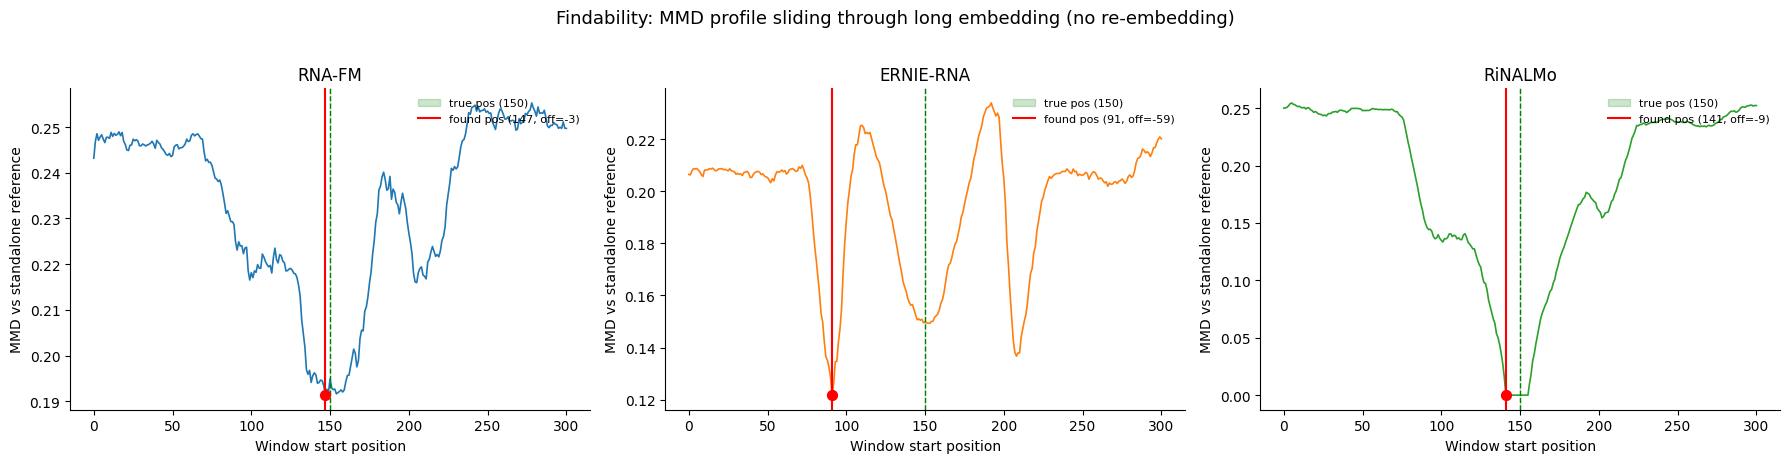

In [9]:
# Plot MMD profiles — where does each model think the tRNA is?
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for idx, mname in enumerate(MODELS):
    ax = axes[idx]
    r = find_results[mname]
    profile = r["mmd_profile"]
    n = len(profile)

    ax.plot(range(n), profile, color=model_colors[mname], lw=1.2)

    # Mark true position
    ax.axvspan(true_start, true_end - core_len, color="green", alpha=0.2, label=f"true pos ({true_start})")
    ax.axvline(true_start, color="green", lw=1, ls="--")

    # Mark found position
    ax.axvline(r["best_pos"], color="red", lw=1.5, ls="-",
               label=f"found pos ({r['best_pos']}, off={r['offset']:+d})")

    ax.scatter([r["best_pos"]], [r["best_mmd"]], color="red", s=50, zorder=5)

    ax.set_xlabel("Window start position")
    ax.set_ylabel("MMD vs standalone reference")
    ax.set_title(f"{mname}")
    ax.legend(fontsize=8, frameon=False, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Findability: MMD profile sliding through long embedding (no re-embedding)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Test 3 — Comparison: slice-from-long vs re-embed-each-window

To quantify the cost of context dependency: at the true tRNA position,
how does `MMD(ref, slice_from_long)` compare to `MMD(ref, re_embed_window)`?

If they're similar, slicing works. If slicing gives much higher MMD,
the model is too context-dependent for the simple approach.

In [10]:
# Compare: at a few positions around the true site,
# slice-from-long MMD vs re-embed-window MMD
PROBE_OFFSETS = [-20, -10, -5, 0, 5, 10, 20]  # relative to true_start

comp_rows = []
for mname, minfo in MODELS.items():
    fn = minfo["emb_fn"]
    ref_emb = fn(core_seq)
    full_emb = fn(full)
    print(f"\n=== {mname} ===")
    print(f"  {'offset':>6s}  {'slice MMD':>10s}  {'re-emb MMD':>10s}  {'ratio':>6s}")

    for off in PROBE_OFFSETS:
        pos = true_start + off
        if pos < 0 or pos + core_len > len(full):
            continue

        # Approach 1: slice from long embedding (cheap)
        slice_emb = full_emb[pos:pos + core_len]
        mmd_slice = sn._compute_mmd(ref_emb, slice_emb)

        # Approach 2: re-embed the window (expensive, current pipeline)
        window_seq = full[pos:pos + core_len]
        reemb = fn(window_seq)
        mmd_reemb = sn._compute_mmd(ref_emb, reemb)

        ratio = mmd_slice / mmd_reemb if mmd_reemb > 1e-6 else float("inf")
        comp_rows.append({
            "model": mname, "offset": off,
            "mmd_slice": mmd_slice, "mmd_reemb": mmd_reemb, "ratio": ratio,
        })
        print(f"  {off:>+6d}  {mmd_slice:>10.4f}  {mmd_reemb:>10.4f}  {ratio:>6.1f}x")

comp_df = pd.DataFrame(comp_rows)


=== RNA-FM ===
  offset   slice MMD  re-emb MMD   ratio
     -20      0.2154      0.2335     0.9x
     -10      0.1962      0.2048     1.0x
      -5      0.1945      0.1973     1.0x
      +0      0.1949      0.0000     infx
      +5      0.1919      0.1892     1.0x
     +10      0.1943      0.1949     1.0x
     +20      0.2055      0.2344     0.9x

=== ERNIE-RNA ===
  offset   slice MMD  re-emb MMD   ratio
     -20      0.1856      0.1889     1.0x
     -10      0.1573      0.0967     1.6x
      -5      0.1507      0.0689     2.2x
      +0      0.1499      0.0000     infx
      +5      0.1501      0.0547     2.7x
     +10      0.1569      0.0854     1.8x
     +20      0.1807      0.1440     1.3x

=== RiNALMo ===
  offset   slice MMD  re-emb MMD   ratio
     -20      0.0829      0.1284     0.6x
     -10      0.0155      0.0315     0.5x
      -5      0.0000      0.0000     infx
      +0      0.0000      0.0000     infx
      +5      0.0000      0.0000     infx
     +10      0.0445      0

## Summary

In [11]:
print("=" * 70)
print("CONTEXT DEPENDENCY SUMMARY")
print("=" * 70)

print("\n1. Embedding stability (flank=150 vs standalone):")
for mname in MODELS:
    sub = stab_df[(stab_df.model == mname) & (stab_df.flank == max(FLANKS))]
    print(f"   {mname:>10s}: cos={sub['mean_cosine'].values[0]:.4f}, "
          f"MMD={sub['mmd'].values[0]:.4f}")

print("\n2. Findability (slide through long embedding):")
for mname in MODELS:
    r = find_results[mname]
    status = "FOUND" if abs(r["offset"]) <= 3 else f"MISSED by {abs(r['offset'])} nt"
    print(f"   {mname:>10s}: best_pos={r['best_pos']}, "
          f"offset={r['offset']:+d} [{status}], MMD={r['best_mmd']:.4f}")

print("\n3. Slice vs re-embed at true position (offset=0):")
for mname in MODELS:
    sub = comp_df[(comp_df.model == mname) & (comp_df.offset == 0)]
    if len(sub) > 0:
        print(f"   {mname:>10s}: slice={sub['mmd_slice'].values[0]:.4f}, "
              f"re-emb={sub['mmd_reemb'].values[0]:.4f}, "
              f"ratio={sub['ratio'].values[0]:.1f}x")

CONTEXT DEPENDENCY SUMMARY

1. Embedding stability (flank=150 vs standalone):
       RNA-FM: cos=0.8338, MMD=0.1949
    ERNIE-RNA: cos=0.5856, MMD=0.1499
      RiNALMo: cos=0.8935, MMD=0.0000

2. Findability (slide through long embedding):
       RNA-FM: best_pos=147, offset=-3 [FOUND], MMD=0.1913
    ERNIE-RNA: best_pos=91, offset=-59 [MISSED by 59 nt], MMD=0.1218
      RiNALMo: best_pos=141, offset=-9 [MISSED by 9 nt], MMD=0.0000

3. Slice vs re-embed at true position (offset=0):
       RNA-FM: slice=0.1949, re-emb=0.0000, ratio=infx
    ERNIE-RNA: slice=0.1499, re-emb=0.0000, ratio=infx
      RiNALMo: slice=0.0000, re-emb=0.0000, ratio=infx
